In [1]:
# ============================================
# Quick Inspection of an .h5ad Dataset
# ============================================

import scanpy as sc

# Load file
adata = sc.read_h5ad("Ma2019_Liver-Biliary.h5ad")

# -------------------------------
# 1. General structure
# -------------------------------
print("=== DATASET OVERVIEW ===")
print(adata)
print("Shape (cells x genes):", adata.shape)

# -------------------------------
# 2. Cell metadata (obs)
# -------------------------------
print("\n=== CELL METADATA (obs) ===")
print("Columns:", adata.obs.columns.tolist())
print(adata.obs.head())

# -------------------------------
# 3. Gene metadata (var)
# -------------------------------
print("\n=== GENE METADATA (var) ===")
print("Columns:", adata.var.columns.tolist())
print(adata.var.head())

# -------------------------------
# 4. Expression matrix info
# -------------------------------
print("\n=== EXPRESSION MATRIX ===")
print("Type:", type(adata.X))
print("Shape:", adata.X.shape)

# -------------------------------
# 5. Additional contents
# -------------------------------
print("\n=== ADDITIONAL FIELDS ===")
print("Layers:", list(adata.layers.keys()))
print("Obsm (embeddings):", list(adata.obsm.keys()))
print("Varm:", list(adata.varm.keys()))
print("Uns (unstructured):", list(adata.uns.keys()))

# -------------------------------
# 6. Example values
# -------------------------------
print("\n=== SAMPLE DATA VALUES ===")
print("First 5 gene names:", adata.var_names[:5])
print("First 5 cell names:", adata.obs_names[:5])

# Show a small slice of the matrix
print("\nMatrix preview (first 5 cells, first 5 genes):")
print(adata[:5, :5].X)

print("\n=== DONE ===")

=== DATASET OVERVIEW ===
AnnData object with n_obs × n_vars = 2463 × 17505
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito', 'log10GenesPerUmi', 'ident'
    uns: 'X_name'
    obsm: 'PCA', 'UMAP'
    layers: 'logcounts'
Shape (cells x genes): (2463, 17505)

=== CELL METADATA (obs) ===
Columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'disease', 'nCount_tmp', 'nFeature_tmp', 'percent.ribo', 'percent.mito', 'log10GenesPerUmi', 'ident']
                                                               orig.ident  \
AAACCTGAGATAGCAT-3,C26,Endothelial,1247,-16.72,...  Ma2019_Liver-Biliary_   
AAACCTGAGATGTAAC-9,H38,Malignant,3524,29.

# SCBM

In [24]:
# ----------------------------
# WHH_TR_h5ad_for_Ma2019 (FULL 1000 EPISODES, OUTPUT PER EPISODE)
# ----------------------------
import warnings
warnings.filterwarnings("ignore")

import math, random, numpy as np, pandas as pd, scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek

# ----------------------------
# Settings
# ----------------------------
H5AD_PATH = "Ma2019_Liver-Biliary.h5ad"
OUTPUT_PATH = "Ma2019_Liver-Biliary_BEST_BALANCER.h5ad"
TEST_SIZE = 0.3
RANDOM_STATE = 42
N_EPISODES = 100
N_SELECT = 5
EPS = 1e-8

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ----------------------------
# Balancers
# ----------------------------
def smote_balance(X, y): return SMOTE(random_state=RANDOM_STATE).fit_resample(X, y)
def ros_balance(X, y): return RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X, y)
def enn_balance(X, y): return EditedNearestNeighbours().fit_resample(X, y)
def smoteenn_balance(X, y): return SMOTEENN(random_state=RANDOM_STATE).fit_resample(X, y)
def smotetomek_balance(X, y): return SMOTETomek(random_state=RANDOM_STATE).fit_resample(X, y)

def sso_balance(X, y):
    Xs, ys = smote_balance(X, y)
    df = pd.concat([pd.DataFrame(Xs), pd.Series(ys, name="lbl")], axis=1)
    counts = df["lbl"].value_counts()
    if counts.shape[0] <= 1:
        return Xs, ys
    min_cnt = counts.min()
    target_majority = int(max(1, min_cnt * 1.2))
    dfs=[]
    for cls, cnt in counts.items():
        cls_df = df[df["lbl"]==cls]
        if cnt > target_majority:
            cls_df = cls_df.sample(target_majority, random_state=RANDOM_STATE)
        dfs.append(cls_df)
    res = pd.concat(dfs).sample(frac=1, random_state=RANDOM_STATE)
    return res.drop(columns="lbl").values, res["lbl"].values

balancer_funcs = [
    ("SSO", sso_balance),
    ("SMOTE", smote_balance),
    ("ENN", enn_balance),
    ("SMOTEENN", smoteenn_balance),
    ("ROS", ros_balance),
    ("SMOTETOMEK", smotetomek_balance),
]
balancer_names = [b[0] for b in balancer_funcs]

# ----------------------------
# Metrics
# ----------------------------
def compute_metrics_for_balancer(func, X_train, y_train, X_val):
    try:
        Xb, yb = func(X_train.copy(), y_train.copy())
    except:
        return {'silhouette':0.0,'davies_bouldin':float('inf'),'calinski_harabasz':0.0}

    try:
        clf = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
        clf.fit(Xb, yb)
        preds = clf.predict(X_val)
    except:
        preds = np.zeros(len(X_val))

    m = {}
    try: m['silhouette'] = float(silhouette_score(X_val, preds))
    except: m['silhouette'] = 0.0
    try: m['davies_bouldin'] = float(davies_bouldin_score(X_val, preds))
    except: m['davies_bouldin'] = float('inf')
    try: m['calinski_harabasz'] = float(calinski_harabasz_score(X_val, preds))
    except: m['calinski_harabasz'] = 0.0

    return m

def normalize_metrics_and_compute_areas(metrics_list):
    sil = np.array([m['silhouette'] for m in metrics_list])
    db  = np.array([m['davies_bouldin'] for m in metrics_list])
    ch  = np.array([m['calinski_harabasz'] for m in metrics_list])

    finite_db = db[np.isfinite(db)]
    max_db = finite_db.max() if finite_db.size > 0 else 1.0
    db = np.where(np.isfinite(db), db, max_db * 2 + 1)

    def mm(a):
        amin, amax = np.nanmin(a), np.nanmax(a)
        return np.zeros_like(a) if math.isclose(amin, amax) else (a-amin)/(amax-amin)

    ns, ndb, nch = mm(sil), mm(db), mm(ch)

    areas=[]
    for i in range(len(metrics_list)):
        s_t = 1 - ns[i]
        db_t = ndb[i]
        ch_t = 1 - nch[i]

        a,b,c = max(s_t,1e-6), max(db_t,1e-6), max(ch_t,1e-6)
        sides = sorted([a,b,c])

        if sides[2] >= sides[0] + sides[1]:
            sides[2] = (sides[0]+sides[1]) * 0.9999

        sa,sb,sc = sides
        s=(sa+sb+sc)/2

        try:
            area = math.sqrt(s*(s-sa)*(s-sb)*(s-sc))
        except:
            area=0

        areas.append(max(0, area))

    return areas

# ----------------------------
# Roulette selection
# ----------------------------
def roulette_select(weights, k):
    w = np.array(weights)
    probs = w / w.sum() if np.any(w > 0) else np.ones_like(w)/len(w)
    rng = np.random.default_rng(RANDOM_STATE)
    picks=[]
    while len(picks) < k:
        choice = rng.choice(len(w), p=probs)
        if choice not in picks:
            picks.append(choice)
    return picks

# ----------------------------
# Pipeline
# ----------------------------
def WHH_pipeline_h5ad(h5ad_path):

    print("\n=== Loading data ===")
    adata = sc.read_h5ad(h5ad_path)

    X = adata.layers["logcounts"]
    X = X.toarray() if not isinstance(X, np.ndarray) else X
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    adata.X = X

    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata = adata[:, adata.var.highly_variable]

    X = adata.X
    y = (adata.obs["cell_type"] == "Malignant").astype(int).values

    print(f"Shape: {X.shape}")
    print("Classes:", np.unique(y, return_counts=True))

    X = StandardScaler().fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    # Initial evaluation
    initial_metrics=[]
    for name,func in balancer_funcs:
        m = compute_metrics_for_balancer(func, X_train, y_train, X_val)
        initial_metrics.append(m)

    areas = normalize_metrics_and_compute_areas(initial_metrics)
    rewards = [1/(a+1) for a in areas]
    cumulative = rewards.copy()

    # Episodes
    for ep in range(1, N_EPISODES+1):
        print(f"\n--- Episode {ep} ---")
        sel_idx = roulette_select(cumulative, N_SELECT)
        sel_metrics=[compute_metrics_for_balancer(balancer_funcs[i][1], X_train, y_train, X_val) for i in sel_idx]
        sel_areas = normalize_metrics_and_compute_areas(sel_metrics)

        for local_i, global_i in enumerate(sel_idx):
            area = sel_areas[local_i]
            reward = 1/(area+1) + np.random.uniform(0, 0.001)
            cumulative[global_i] += reward
            print(f"    -> {balancer_names[global_i]:12s} TR={area:.6f} reward+={reward:.6f} cum={cumulative[global_i]:.6f}")

    # Final best balancer
    best_idx = np.argmax(cumulative)
    best_name, best_func = balancer_funcs[best_idx]

    print(f"\n=== Best balancer after {N_EPISODES} episodes: {best_name} ===")

    # Save the best balancer name for future reference
    with open("BEST_BALANCER.txt", "w") as f:
        f.write(best_name)

    return best_name

# ----------------------------
# Run
# ----------------------------
if __name__=="__main__":
    WHH_pipeline_h5ad(H5AD_PATH)


=== Loading data ===
Shape: (2463, 2000)
Classes: (array([0, 1]), array([1001, 1462], dtype=int64))

--- Episode 1 ---
    -> ROS          TR=0.000001 reward+=1.000374 cum=2.000374
    -> ENN          TR=0.000001 reward+=1.000950 cum=2.000950
    -> SMOTETOMEK   TR=0.000001 reward+=1.000731 cum=2.000731
    -> SSO          TR=0.000001 reward+=1.000598 cum=2.000598
    -> SMOTEENN     TR=0.000001 reward+=1.000156 cum=2.000155

--- Episode 2 ---
    -> ROS          TR=0.000001 reward+=1.000155 cum=3.000529
    -> ENN          TR=0.000001 reward+=1.000058 cum=3.001007
    -> SMOTETOMEK   TR=0.000001 reward+=1.000866 cum=3.001597
    -> SSO          TR=0.000001 reward+=1.000601 cum=3.001198
    -> SMOTE        TR=0.000001 reward+=1.000708 cum=2.000707

--- Episode 3 ---
    -> ROS          TR=0.000001 reward+=1.000020 cum=4.000549
    -> ENN          TR=0.000001 reward+=1.000969 cum=4.001977
    -> SMOTETOMEK   TR=0.000001 reward+=1.000832 cum=4.002429
    -> SSO          TR=0.000001 rewa

In [25]:
# ----------------------------
# ENN balancing for Ma2019_Liver-Biliary
# ----------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Settings
# ----------------------------
H5AD_PATH = "Ma2019_Liver-Biliary.h5ad"
OUTPUT_H5AD = "Ma2019_Liver-Biliary_ENN_Balanced.h5ad"
OUTPUT_CSV = "Ma2019_Liver-Biliary_ENN_Balanced_labels.csv"
RANDOM_STATE = 42

# ----------------------------
# Load original data
# ----------------------------
adata = sc.read_h5ad(H5AD_PATH)

# Use logcounts
X = adata.layers["logcounts"]
X = X.toarray() if not isinstance(X, np.ndarray) else X
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Define binary label: Malignant = 1, Others = 0
y = (adata.obs["cell_type"] == "Malignant").astype(int).values

# ----------------------------
# Apply ENN for under-sampling (clean majority class)
# ----------------------------
enn = EditedNearestNeighbours()
X_bal, y_bal = enn.fit_resample(X, y)

print(f"Original shape: {X.shape}, Balanced shape: {X_bal.shape}")

# ----------------------------
# Scale features
# ----------------------------
X_bal = StandardScaler().fit_transform(X_bal)

# ----------------------------
# Save balanced data to new AnnData
# ----------------------------
adata_bal = sc.AnnData(X=X_bal)

# Copy obs and var for the selected cells
# ENN returns indices of selected samples
# We use `enn.sample_indices_` to map to original obs
# Note: If sample_indices_ is not available (older versions), we match manually
selected_idx = enn.sample_indices_ if hasattr(enn, "sample_indices_") else np.arange(len(y_bal))
adata_bal.obs = adata.obs.iloc[selected_idx].copy()
adata_bal.var = adata.var.copy()

# Save logcounts layer
adata_bal.layers["logcounts"] = X_bal

# Save balanced H5AD
adata_bal.write_h5ad(OUTPUT_H5AD)
print(f"Balanced H5AD saved to {OUTPUT_H5AD}")

# ----------------------------
# Save a small CSV table with cell names and new labels
# ----------------------------
df_labels = pd.DataFrame({
    "cell_id": adata_bal.obs_names,
    "cell_type": ["Malignant" if lbl==1 else "Non-Malignant" for lbl in y_bal]
})
df_labels.to_csv(OUTPUT_CSV, index=False)
print(f"Balanced label CSV saved to {OUTPUT_CSV}")

Original shape: (2463, 17505), Balanced shape: (2463, 17505)
Balanced H5AD saved to Ma2019_Liver-Biliary_ENN_Balanced.h5ad
Balanced label CSV saved to Ma2019_Liver-Biliary_ENN_Balanced_labels.csv


In [32]:
# ----------------------------
# Compare Class Distribution: Original vs ENN Balanced
# ----------------------------
import scanpy as sc
import numpy as np

# ----------------------------
# Load data
# ----------------------------
adata_orig = sc.read_h5ad("Ma2019_Liver-Biliary.h5ad")
adata_enn  = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")

# ----------------------------
# Define labels
# ----------------------------
y_orig = (adata_orig.obs["cell_type"] == "Malignant").astype(int)
y_enn  = (adata_enn.obs["cell_type"] == "Malignant").astype(int)

# ----------------------------
# Count classes
# ----------------------------
def get_class_counts(y):
    unique, counts = np.unique(y, return_counts=True)
    return dict(zip(unique, counts))

counts_orig = get_class_counts(y_orig)
counts_enn  = get_class_counts(y_enn)

# ----------------------------
# Print results
# ----------------------------
print("\n=== ORIGINAL DATA ===")
for cls, cnt in counts_orig.items():
    label = "Malignant" if cls == 1 else "Non-Malignant"
    print(f"{label}: {cnt}")

minority_orig = min(counts_orig.values())
majority_orig = max(counts_orig.values())
print(f"Minority size: {minority_orig}, Majority size: {majority_orig}, Ratio: {majority_orig/minority_orig:.2f}")

print("\n=== ENN BALANCED DATA ===")
for cls, cnt in counts_enn.items():
    label = "Malignant" if cls == 1 else "Non-Malignant"
    print(f"{label}: {cnt}")

minority_enn = min(counts_enn.values())
majority_enn = max(counts_enn.values())
print(f"Minority size: {minority_enn}, Majority size: {majority_enn}, Ratio: {majority_enn/minority_enn:.2f}")


=== ORIGINAL DATA ===
Non-Malignant: 1001
Malignant: 1462
Minority size: 1001, Majority size: 1462, Ratio: 1.46

=== ENN BALANCED DATA ===
Non-Malignant: 1001
Malignant: 1462
Minority size: 1001, Majority size: 1462, Ratio: 1.46



=== ORIGINAL DATA ===
Non-Malignant: 1001
Malignant: 1462
Minority size: 1001, Majority size: 1462, Ratio: 1.46

=== ENN BALANCED DATA ===
Non-Malignant: 1001
Malignant: 1462
Minority size: 1001, Majority size: 1462, Ratio: 1.46


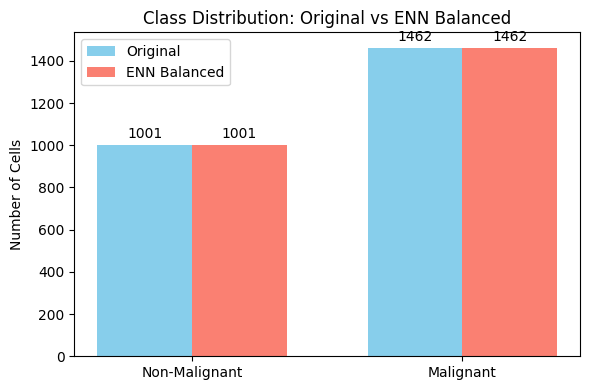

In [33]:
# ----------------------------
# Compare Class Distribution: Original vs ENN Balanced (with plot)
# ----------------------------
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
adata_orig = sc.read_h5ad("Ma2019_Liver-Biliary.h5ad")
adata_enn  = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")

# ----------------------------
# Define labels
# ----------------------------
y_orig = (adata_orig.obs["cell_type"] == "Malignant").astype(int)
y_enn  = (adata_enn.obs["cell_type"] == "Malignant").astype(int)

# ----------------------------
# Count classes
# ----------------------------
def get_class_counts(y):
    unique, counts = np.unique(y, return_counts=True)
    return dict(zip(unique, counts))

counts_orig = get_class_counts(y_orig)
counts_enn  = get_class_counts(y_enn)

# ----------------------------
# Print results
# ----------------------------
print("\n=== ORIGINAL DATA ===")
for cls, cnt in counts_orig.items():
    label = "Malignant" if cls == 1 else "Non-Malignant"
    print(f"{label}: {cnt}")
minority_orig = min(counts_orig.values())
majority_orig = max(counts_orig.values())
print(f"Minority size: {minority_orig}, Majority size: {majority_orig}, Ratio: {majority_orig/minority_orig:.2f}")

print("\n=== ENN BALANCED DATA ===")
for cls, cnt in counts_enn.items():
    label = "Malignant" if cls == 1 else "Non-Malignant"
    print(f"{label}: {cnt}")
minority_enn = min(counts_enn.values())
majority_enn = max(counts_enn.values())
print(f"Minority size: {minority_enn}, Majority size: {majority_enn}, Ratio: {majority_enn/minority_enn:.2f}")

# ----------------------------
# Plot comparison
# ----------------------------
labels = ["Non-Malignant", "Malignant"]
orig_values = [counts_orig.get(0,0), counts_orig.get(1,0)]
enn_values  = [counts_enn.get(0,0), counts_enn.get(1,0)]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))
rects1 = ax.bar(x - width/2, orig_values, width, label='Original', color='skyblue')
rects2 = ax.bar(x + width/2, enn_values, width, label='ENN Balanced', color='salmon')

ax.set_ylabel("Number of Cells")
ax.set_title("Class Distribution: Original vs ENN Balanced")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


=== ORIGINAL DATA ===
Endothelial: 433
Malignant: 1462
Fibroblast: 221
Macrophage: 268
T_cell: 66
hpc-like: 8
B_cell: 5
Minority size: 5, Majority size: 1462, Ratio: 292.40

=== ENN BALANCED DATA ===
Endothelial: 433
Fibroblast: 221
Macrophage: 268
T_cell: 66
hpc-like: 8
B_cell: 5
Malignant: 1462
Minority size: 5, Majority size: 1462, Ratio: 292.40


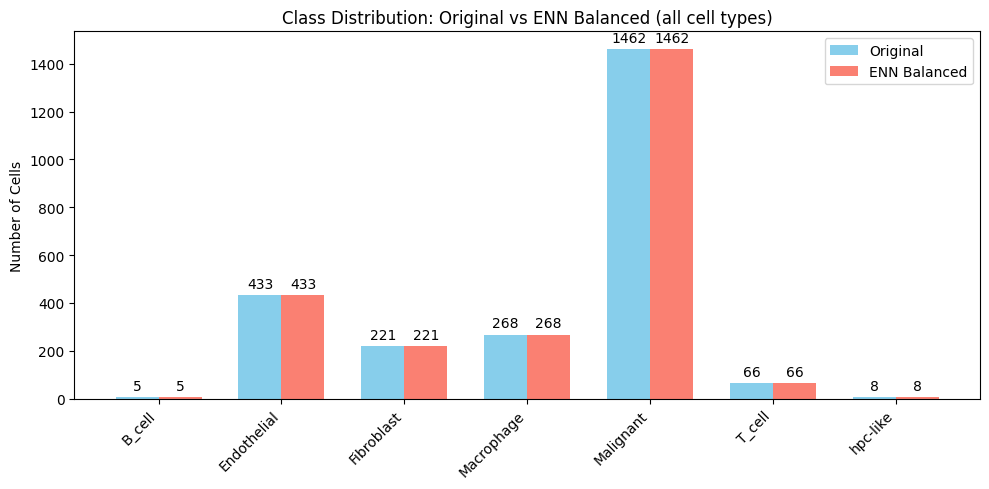

In [34]:
# ----------------------------
# Compare Class Distribution: Original vs ENN Balanced (all cell types)
# ----------------------------
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ----------------------------
# Load data
# ----------------------------
adata_orig = sc.read_h5ad("Ma2019_Liver-Biliary.h5ad")
adata_enn  = sc.read_h5ad("Ma2019_Liver-Biliary_ENN_Balanced.h5ad")

# ----------------------------
# Count all cell types
# ----------------------------
def get_class_counts_all(adata):
    return dict(Counter(adata.obs["cell_type"]))

counts_orig = get_class_counts_all(adata_orig)
counts_enn  = get_class_counts_all(adata_enn)

# ----------------------------
# Print results
# ----------------------------
print("\n=== ORIGINAL DATA ===")
for cls, cnt in counts_orig.items():
    print(f"{cls}: {cnt}")
minority_orig = min(counts_orig.values())
majority_orig = max(counts_orig.values())
print(f"Minority size: {minority_orig}, Majority size: {majority_orig}, Ratio: {majority_orig/minority_orig:.2f}")

print("\n=== ENN BALANCED DATA ===")
for cls, cnt in counts_enn.items():
    print(f"{cls}: {cnt}")
minority_enn = min(counts_enn.values())
majority_enn = max(counts_enn.values())
print(f"Minority size: {minority_enn}, Majority size: {majority_enn}, Ratio: {majority_enn/minority_enn:.2f}")

# ----------------------------
# Plot comparison
# ----------------------------
all_labels = sorted(list(set(list(counts_orig.keys()) + list(counts_enn.keys()))))
orig_values = [counts_orig.get(lbl,0) for lbl in all_labels]
enn_values  = [counts_enn.get(lbl,0) for lbl in all_labels]

x = np.arange(len(all_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, orig_values, width, label='Original', color='skyblue')
rects2 = ax.bar(x + width/2, enn_values, width, label='ENN Balanced', color='salmon')

ax.set_ylabel("Number of Cells")
ax.set_title("Class Distribution: Original vs ENN Balanced (all cell types)")
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=45, ha='right')
ax.legend()

# Annotate bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()